In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, explained_variance_score
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

In [65]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

keras     : 3.10.0
plotly    : 5.24.1
numpy     : 1.26.4
seaborn   : 0.13.2
pandas    : 2.2.2
sklearn   : 1.5.1
tensorflow: 2.19.0
matplotlib: 3.9.2



In [66]:
df = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/Dados/commodities.csv")

In [67]:
df.index = pd.to_datetime(df['data'], format = '%Y-%m-%d')

In [68]:
del df['data']

In [69]:
df.head()

,petroleo_bruto,minerio_ferro,ouro,arroz,feijao,milho,soja,trigo,cafe,algodao,umidade
data,,,,,,,,,,,
2012-12-01,323,455,3102.61,423.45,844.0,468.0,578.0,28.67,207.70504,117.7,79.261905
2013-01-01,345,546,3100.45,415.85,799.0,485.0,557.0,24.49,228.94287,4.5,82.193548
2013-02-01,362,595,3199.41,410.77,718.0,466.0,552.0,22.06,238.41747,25.1,74.839286
2013-03-01,376,636,3281.67,414.82,614.0,442.0,574.0,21.64,218.47599,53.6,77.935484
2013-04-01,383,738,3261.65,451.04,619.0,429.0,595.0,22.30,226.15010,166.0,80.450000


In [70]:
train_size = int(len(df) * 0.8)
teste_size = len(df) - train_size

In [71]:
train = df.iloc[0:train_size]

In [72]:
test = df.iloc[train_size:len(df)]

In [73]:
print('Amostra de Treino:', len(train))
print('Amostra de Teste:', len(test))

Amostra de Treino: 99
Amostra de Teste: 25


In [74]:
variaveis_preditoras = ['minerio_ferro',
                        'ouro',
                        'arroz',
                        'feijao',
                        'milho',
                        'soja',
                        'trigo',
                        'cafe',
                        'algodao',
                        'umidade']

In [75]:
scaler_preditores = MinMaxScaler()

In [76]:
scaler_preditores = scaler_preditores.fit(train[variaveis_preditoras].to_numpy())

In [77]:
train.loc[:, variaveis_preditoras] = scaler_preditores.transform(train[variaveis_preditoras].to_numpy())

In [78]:
test.loc[:, variaveis_preditoras] = scaler_preditores.transform(test[variaveis_preditoras].to_numpy())

In [79]:
scaler_target = MinMaxScaler()

In [80]:
scaler_target = scaler_target.fit(train[['petroleo_bruto']])

In [81]:
train['petroleo_bruto'] = scaler_target.transform(train[['petroleo_bruto']])

In [82]:
test['petroleo_bruto'] = scaler_target.transform(test[['petroleo_bruto']])

In [83]:
def createDataset(X, y, time_steps):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        data = X.iloc[i:(i + time_steps)].values
        Xs.append(data)
        ys.append(y.iloc[i + time_steps])

    return np.array(Xs), np.array(ys)

In [84]:
time_steps = 3

In [85]:
X_train, y_train = createDataset(train, train.petroleo_bruto, time_steps) 

In [86]:
X_test, y_test = createDataset(test, test.petroleo_bruto, time_steps) 

In [87]:
modelo_gru = tf.keras.Sequential()
modelo_gru.add(tf.keras.layers.GRU(units = 128, input_shape = (X_train.shape[1], X_train.shape[2])))
modelo_gru.add(tf.keras.layers.Dropout(rate = 0.2))
modelo_gru.add(tf.keras.layers.Dense(units = 1))

In [88]:
modelo_gru.compile(loss = 'mean_squared_error', optimizer = 'adam')

In [89]:
modelo_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 128)            │        54,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,273 (212.00 KB)

 Trainable params: 54,273 (212.00 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
%%time
modelo_gru_history = modelo_gru.fit(X_train,
                                    y_train,
                                    epochs = 100,
                                    batch_size = 32,
                                    validation_split = 0.1,
                                    shuffle = False)

Epoch 1/100


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - loss: 0.4453 - val_loss: 0.0577
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1483 - val_loss: 0.0302
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0330 - val_loss: 0.1300
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0559 - val_loss: 0.2463
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0997 - val_loss: 0.2637
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1100 - val_loss: 0.1953
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0772 - val_loss: 0.1179
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0474 - val_loss: 0.0655
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0335 - val_loss: 0.0401
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0327 - val_loss: 0.0310
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0326 - val_loss: 0.0313
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0257 - val_loss: 0.0377


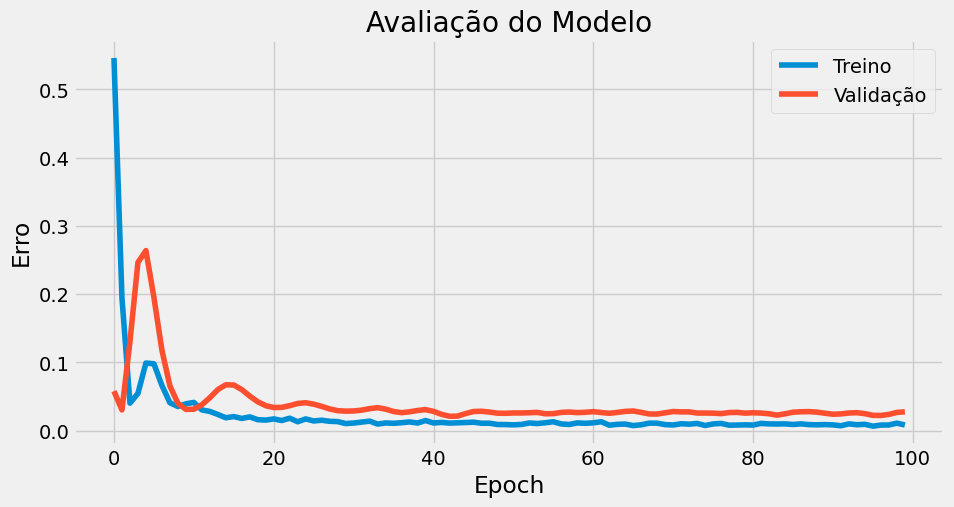

In [91]:
plt.plot(modelo_gru_history.history['loss'])
plt.plot(modelo_gru_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [92]:
y_pred = modelo_gru.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


In [93]:
y_pred

array([[ 0.1163144 ],
       [ 0.12475573],
       [ 0.14586885],
       [ 0.12999424],
       [ 0.06615362],
       [ 0.04263805],
       [ 0.02793153],
       [ 0.02277528],
       [-0.01067512],
       [-0.02852909],
       [-0.04030129],
       [-0.03051015],
       [-0.01448905],
       [ 0.00489837],
       [ 0.02741143],
       [ 0.00298239],
       [-0.04683667],
       [-0.03654503],
       [ 0.10092434],
       [ 0.17630558],
       [ 0.14199398],
       [ 0.09816527]], dtype=float32)

In [94]:
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1, -1))

In [95]:
y_train_inv = y_train_inv.flatten()
y_test_inv = y_test_inv.flatten()
y_pred_inv = y_pred_inv.flatten()

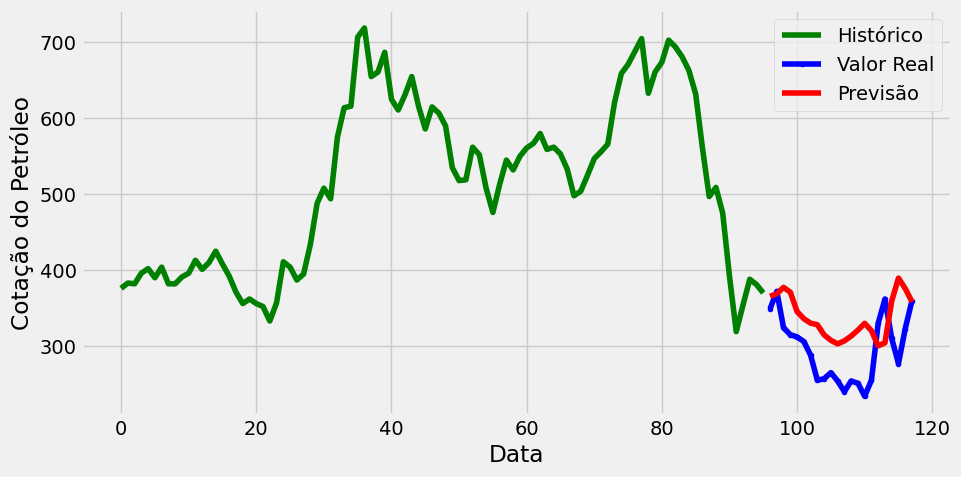

In [96]:
plt.plot(np.arange(0, len(y_train)),
         y_train_inv,
         color = 'green',
         label = 'Histórico')

plt.plot(np.arange(len(y_train),
                   len(y_train) + len(y_test)),
                y_test_inv,
                color = 'blue',
                marker = '.',
                label = 'Valor Real')

plt.plot(np.arange(len(y_train),
                   len(y_train) + len(y_test)),
                y_pred_inv,
                color = 'red',
                label = 'Previsão')

plt.ylabel('Cotação do Petróleo')
plt.xlabel('Data')
plt.legend()
plt.show()

In [97]:
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [98]:
MDA_mlp = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_mlp)

MAE_mlp = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_mlp)

MSE_mlp = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_mlp)

RMSE_mlp = mean_squared_error(y_test_inv, y_pred_inv, squared = False)
print('RMSE:', RMSE_mlp)

EVS_mlp = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_mlp)

MDA: 0.42857142857142855
MAE: 50.81177867542613
MSE: 3243.654784316366
RMSE: 56.95309284241169
EVS Score: 0.19422852173969796
